In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import json
import joblib
from sklearn.model_selection import train_test_split, cross_val_score

from src.train_models import train_models
from src.evaluate_models import evaluate_models


# Load PROCESSED DATA

In [2]:
df = pd.read_csv("../data/processed/clean_data.csv")

print(df.shape)
df.head()



(20071, 39)


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Ct,Avg_Utilization_Ratio,Year,...,"Date_Leave_Q1,2019","Date_Leave_Q2,2018","Date_Leave_Q2,2019","Date_Leave_Q3,2018","Date_Leave_Q3,2019","Date_Leave_Q4,2018","Date_Leave_Q4,2019","Date_Leave_none,2018","Date_Leave_none,2019",target
0,65,0,36,3,1438.3,747,691.3,24,0.519,2018,...,False,False,False,False,False,False,False,True,False,0
1,47,1,36,5,5756.0,0,5756.0,44,0.000,2018,...,False,False,False,False,False,False,False,True,False,0
2,48,1,48,5,5756.0,990,5756.0,25,0.170,2019,...,False,False,False,False,False,False,False,False,True,0
3,65,0,65,4,4315.0,393,3598.0,73,0.090,2019,...,False,False,False,False,False,False,False,False,True,0
4,64,0,53,4,4315.0,717,3598.0,51,0.166,2018,...,False,False,False,False,False,False,False,True,False,0


# Separate Target



In [3]:
y = df["target"]
X = df.drop("target", axis=1)

print(X.shape)

(20071, 38)


# Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
drop_cols = [
    # strong behavioral signals
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Avg_Utilization_Ratio",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Months_on_book",
]

X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# Train Models

In [6]:
models = train_models(X_train, y_train)
print("Models:", list(models.keys()))

Models: ['logistic_regression', 'random_forest', 'xgboost']


# Evaluate

In [7]:
metrics = evaluate_models(models, X_test, y_test)

import pandas as pd
print(pd.DataFrame(metrics).T)

                     roc_auc   f1  recall  precision
logistic_regression      1.0  1.0     1.0        1.0
random_forest            1.0  1.0     1.0        1.0
xgboost                  1.0  1.0     1.0        1.0


# Cross- Validation

In [8]:
model = models["xgboost"]

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")

print("CV Scores:", scores)
print("Average ROC-AUC:", scores.mean())

CV Scores: [1. 1. 1. 1. 1.]
Average ROC-AUC: 1.0


In [9]:
models = train_models(X_train, y_train)
print("Models trained:", list(models.keys()))

Models trained: ['logistic_regression', 'random_forest', 'xgboost']


In [10]:
metrics = evaluate_models(models, X_test, y_test)
print("\nModel Performance:")
print(pd.DataFrame(metrics).T)


Model Performance:
                     roc_auc   f1  recall  precision
logistic_regression      1.0  1.0     1.0        1.0
random_forest            1.0  1.0     1.0        1.0
xgboost                  1.0  1.0     1.0        1.0


In [11]:
with open("../models/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("\nMetrics saved successfully!")


Metrics saved successfully!


In [12]:
joblib.dump(models["logistic_regression"], "../models/logistic_regression.pkl")
joblib.dump(models["random_forest"], "../models/random_forest.pkl")
joblib.dump(models["xgboost"], "../models/xgboost.pkl")
print("Models saved successfully!")

Models saved successfully!


In [15]:
# ----------------------------
# Risk scoring system
# ----------------------------
from sklearn.calibration import CalibratedClassifierCV

# Use your trained model
base_model = models["xgboost"]

# Calibrate it
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

# Get calibrated probabilities
probs = calibrated_model.predict_proba(X_test)[:, 1]

# Create dataframe
import pandas as pd
risk_df = pd.DataFrame({
    "risk_score": probs
})

import numpy as np

# sort scores
sorted_scores = np.sort(risk_df["risk_score"])

# pick breakpoints manually
low_thr = sorted_scores[int(len(sorted_scores)*0.5)]
high_thr = sorted_scores[int(len(sorted_scores)*0.9)]

def categorize(p):
    if p < 0.5:
        return "Low"
    else:
        return "High"

risk_df["risk_level"] = risk_df["risk_score"].apply(categorize)

# Save
import os
os.makedirs("../outputs/predictions", exist_ok=True)

risk_df.to_csv("../outputs/predictions/risk_scores.csv", index=False)

print(risk_df.describe())

        risk_score
count  4015.000000
mean      0.131000
std       0.336511
min       0.000357
25%       0.000357
50%       0.000357
75%       0.000357
max       0.997568


<Axes: xlabel='risk_level', ylabel='count'>

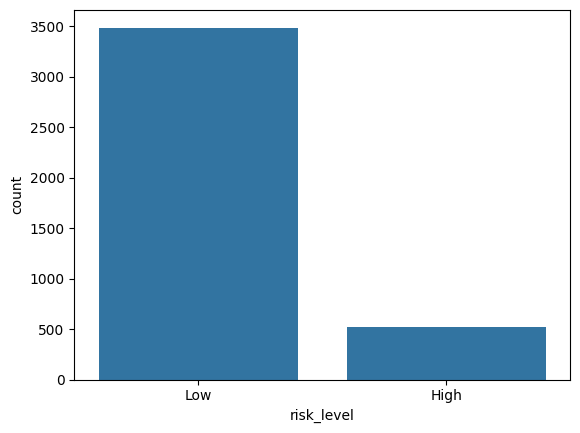

In [16]:
import seaborn as sns
sns.countplot(x="risk_level", data=risk_df)